## 1 | Datensatz kurz vorgestellt

**Quelle:** Hotel Booking Demand Dataset (Kaggle / Antonio, Almeida & Nunes, 2019).

Der Datensatz enthaelt ~119.000 Hotelbuchungen (Resort- und Stadthotel) mit 31 Merkmalen
wie Vorlaufzeit, Gaestezahl, Zimmertyp, Marktsegment und Sonderwuensche.

**Zielvariable:** `reservation_status` mit 3 Klassen:
- **Check-Out** – Gast hat eingecheckt und ausgecheckt
- **Canceled** – Buchung wurde storniert
- **No-Show** – Gast ist nicht erschienen

**Achtung Data Leakage:** Die Spalten `is_canceled` und `reservation_status_date` werden
entfernt, da sie direkt aus dem Target abgeleitet sind.

In [1]:
import sys; sys.path.insert(0, '..')
import yaml
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from src.data_loading import set_seeds
from src.plotting import setup_plot_style

cfg = yaml.safe_load(open(Path('../configs/default.yaml')))
set_seeds(cfg['random_seed'])
setup_plot_style(cfg)

In [2]:
# Daten laden
hb_cfg = cfg['hotel_bookings']
raw_path = Path('..') / cfg['paths']['raw_data']
df = pd.read_csv(raw_path / hb_cfg['file'])
print(f'Shape: {df.shape}')
df.head()

Shape: (119390, 31)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,company_agent
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,99999.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,99999.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,99999.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,304.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,240.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## 2 | Exploratory Data Analysis (EDA)

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

Prozentual:
reservation_status
Check-Out    62.96
Canceled     36.03
No-Show       1.01
Name: proportion, dtype: float64


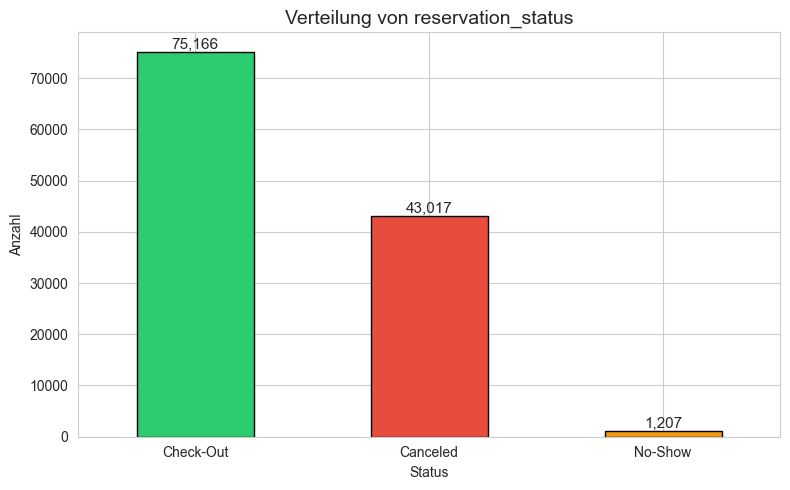

In [4]:
# Klassenverteilung der Zielvariable
target = hb_cfg['target']
print(df[target].value_counts())
print(f'\nProzentual:\n{df[target].value_counts(normalize=True).round(4) * 100}')

plt.figure(figsize=(8, 5))
ax = df[target].value_counts().plot.bar(color=['#2ecc71', '#e74c3c', '#f39c12'], edgecolor='black')
plt.title('Verteilung von reservation_status', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Anzahl')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

Die Klassen sind **stark unbalanciert**: Check-Out und Canceled dominieren, 
No-Show macht nur einen sehr kleinen Anteil aus. Das muss beim Modelltraining beruecksichtigt werden.

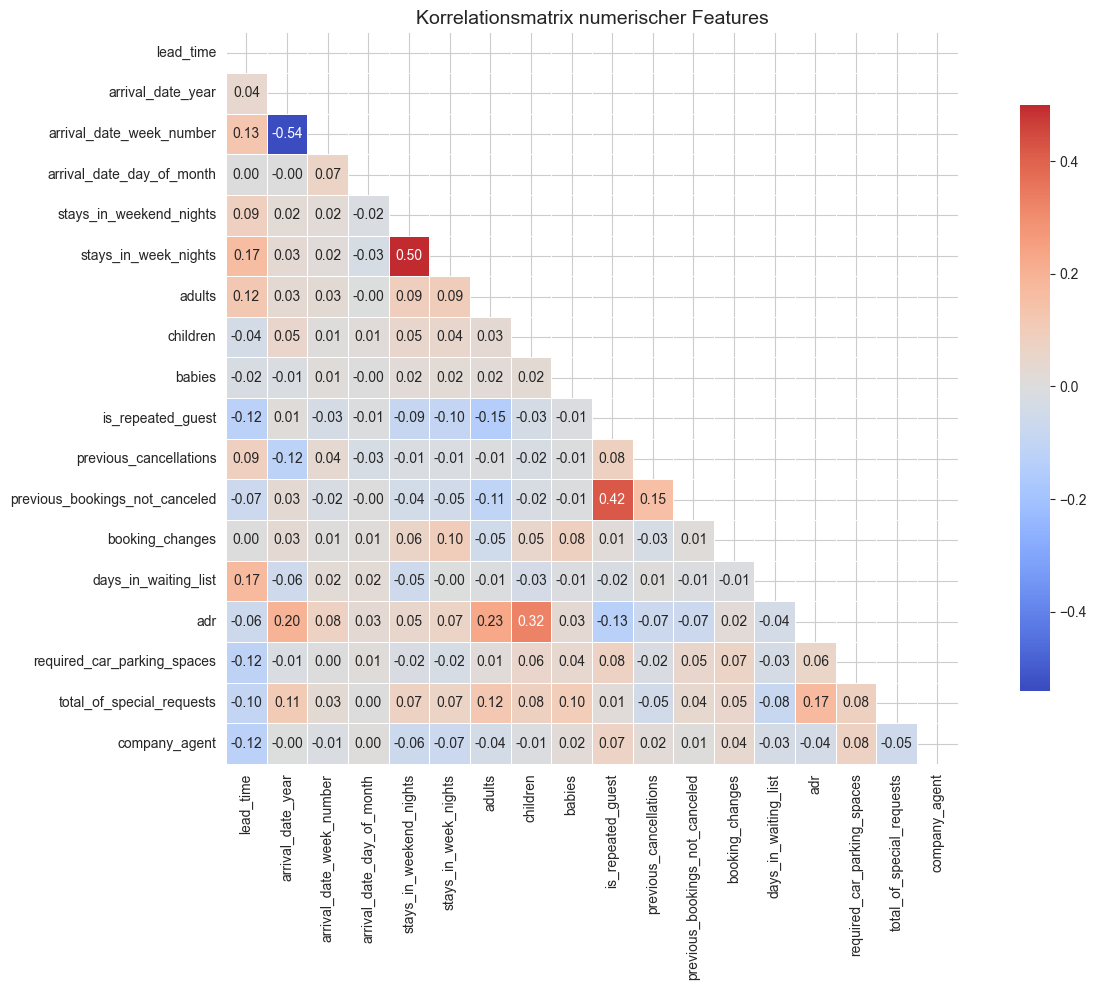

In [5]:
# Korrelation numerischer Features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Leakage-Spalten ausschliessen
num_cols = [c for c in num_cols if c not in hb_cfg['drop_columns']]

plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Korrelationsmatrix numerischer Features', fontsize=14)
plt.tight_layout()
plt.show()

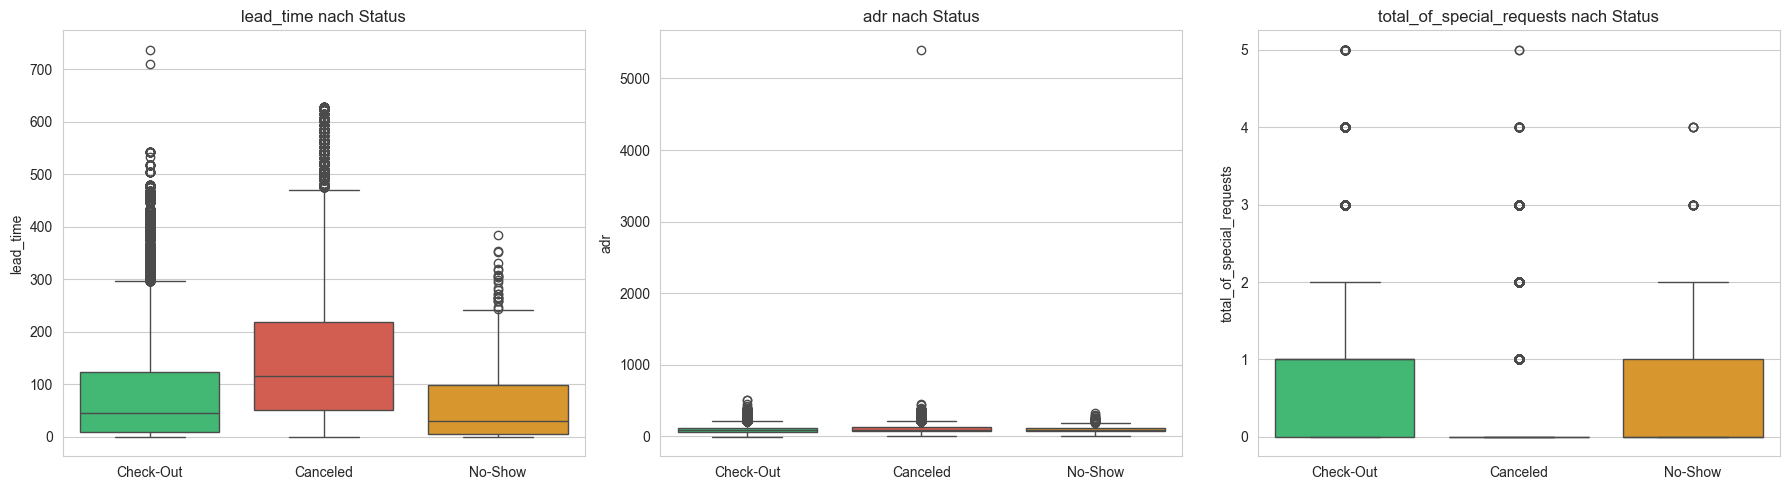

In [6]:
# Verteilung wichtiger Features nach reservation_status
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['lead_time', 'adr', 'total_of_special_requests']):
    sns.boxplot(data=df, x=target, y=col, ax=ax, palette=['#2ecc71', '#e74c3c', '#f39c12'])
    ax.set_title(f'{col} nach Status', fontsize=12)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

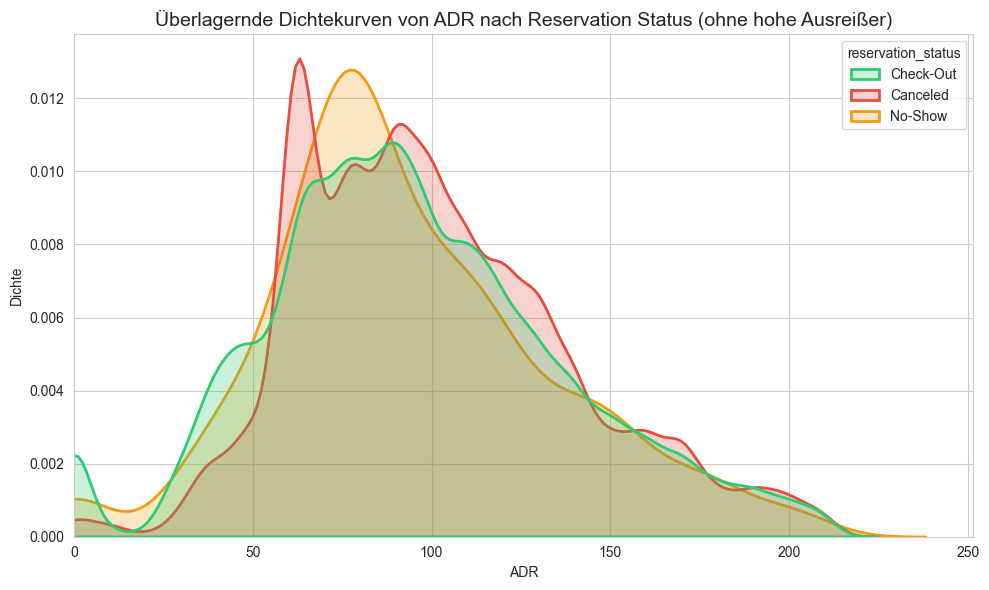

In [18]:
# Zu hohe positive ADR-Ausreißer entfernen (IQR-Methode, nur oberes Ende)
q1, q3 = df['adr'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

df_kde = df[(df['adr'] >= 0) & (df['adr'] <= upper_bound)]

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_kde,
    x='adr',
    hue=target,  # = 'reservation_status'
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=2,
    palette=['#2ecc71', '#e74c3c', '#f39c12']
)

plt.title('Überlagernde Dichtekurven von ADR nach Reservation Status (ohne hohe Ausreißer)', fontsize=14)
plt.xlabel('ADR')
plt.ylabel('Dichte')
plt.xlim(left=0)
plt.tight_layout()
plt.show()

No-Show Statistiken nach Deposit Type:


,No-Show Rate (%),Mean ADR (No-Show),Mean ADR (Other),Count No-Show,Count Total
deposit_type,,,,,
No Deposit,1.12,96.90,103.60,1172.0,104641.0
Non Refund,0.23,79.97,89.99,34.0,14587.0
Refundable,0.62,48.00,76.38,1.0,162.0


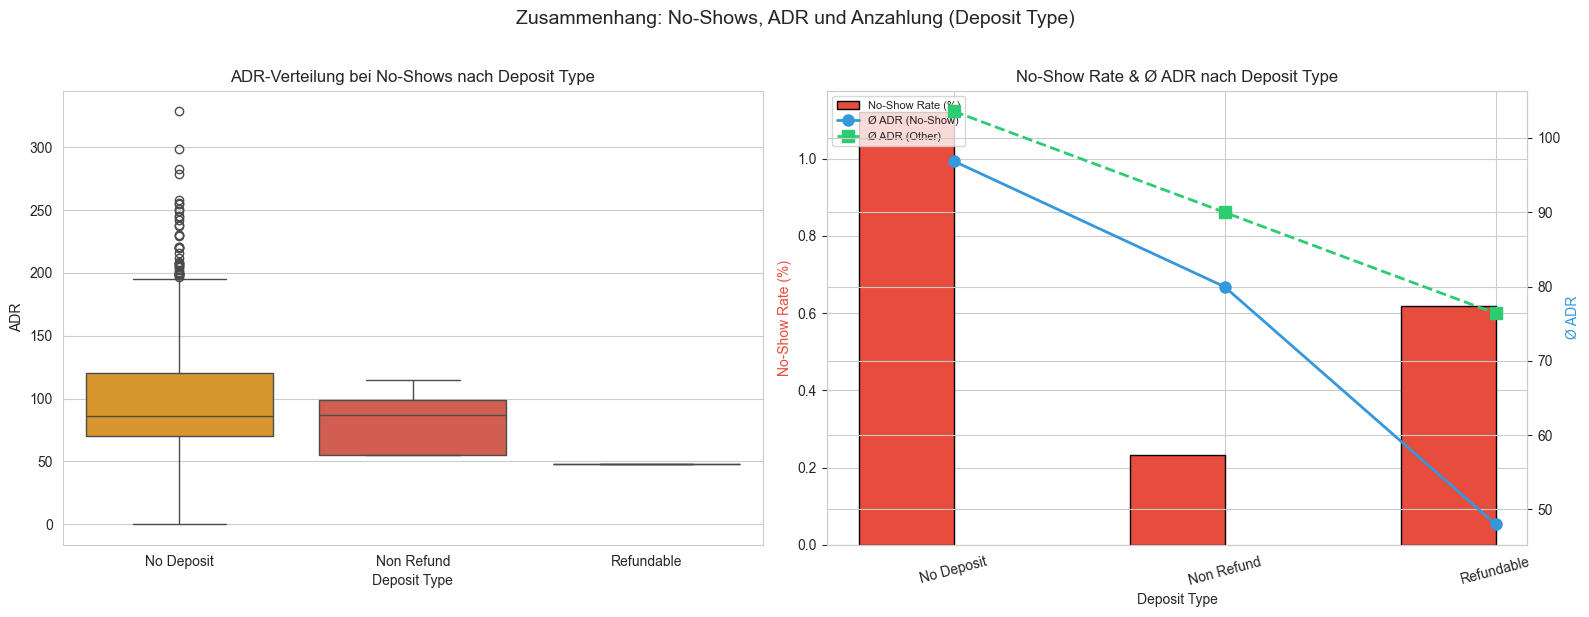

In [19]:
# No-Shows vs. ADR und Deposit Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) Boxplot: ADR nach Deposit Type, nur No-Shows
df_noshow = df[df[target] == 'No-Show']

sns.boxplot(data=df_noshow, x='deposit_type', y='adr', ax=axes[0],
            palette=['#f39c12', '#e74c3c', '#2ecc71'], order=['No Deposit', 'Non Refund', 'Refundable'])
axes[0].set_title('ADR-Verteilung bei No-Shows nach Deposit Type', fontsize=12)
axes[0].set_xlabel('Deposit Type')
axes[0].set_ylabel('ADR')

# 2) Anteil No-Shows nach Deposit Type mit mittlerer ADR
noshow_stats = df.groupby('deposit_type').apply(
    lambda g: pd.Series({
        'No-Show Rate (%)': (g[target] == 'No-Show').mean() * 100,
        'Mean ADR (No-Show)': g.loc[g[target] == 'No-Show', 'adr'].mean(),
        'Mean ADR (Other)': g.loc[g[target] != 'No-Show', 'adr'].mean(),
        'Count No-Show': (g[target] == 'No-Show').sum(),
        'Count Total': len(g),
    })
)
print('No-Show Statistiken nach Deposit Type:')
display(noshow_stats.round(2))

# Grouped Bar: No-Show Rate und mittlere ADR
ax2 = axes[1]
x = np.arange(len(noshow_stats))
width = 0.35

bars1 = ax2.bar(x - width/2, noshow_stats['No-Show Rate (%)'], width,
                label='No-Show Rate (%)', color='#e74c3c', edgecolor='black')
ax2.set_ylabel('No-Show Rate (%)', color='#e74c3c')
ax2.set_xlabel('Deposit Type')
ax2.set_xticks(x)
ax2.set_xticklabels(noshow_stats.index, rotation=15)
ax2.set_title('No-Show Rate & Ø ADR nach Deposit Type', fontsize=12)

# Zweite Y-Achse fuer ADR
ax3 = ax2.twinx()
ax3.plot(x, noshow_stats['Mean ADR (No-Show)'], 'o-', color='#3498db',
         linewidth=2, markersize=8, label='Ø ADR (No-Show)')
ax3.plot(x, noshow_stats['Mean ADR (Other)'], 's--', color='#2ecc71',
         linewidth=2, markersize=8, label='Ø ADR (Other)')
ax3.set_ylabel('Ø ADR', color='#3498db')

# Legenden kombinieren
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.suptitle('Zusammenhang: No-Shows, ADR und Anzahlung (Deposit Type)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

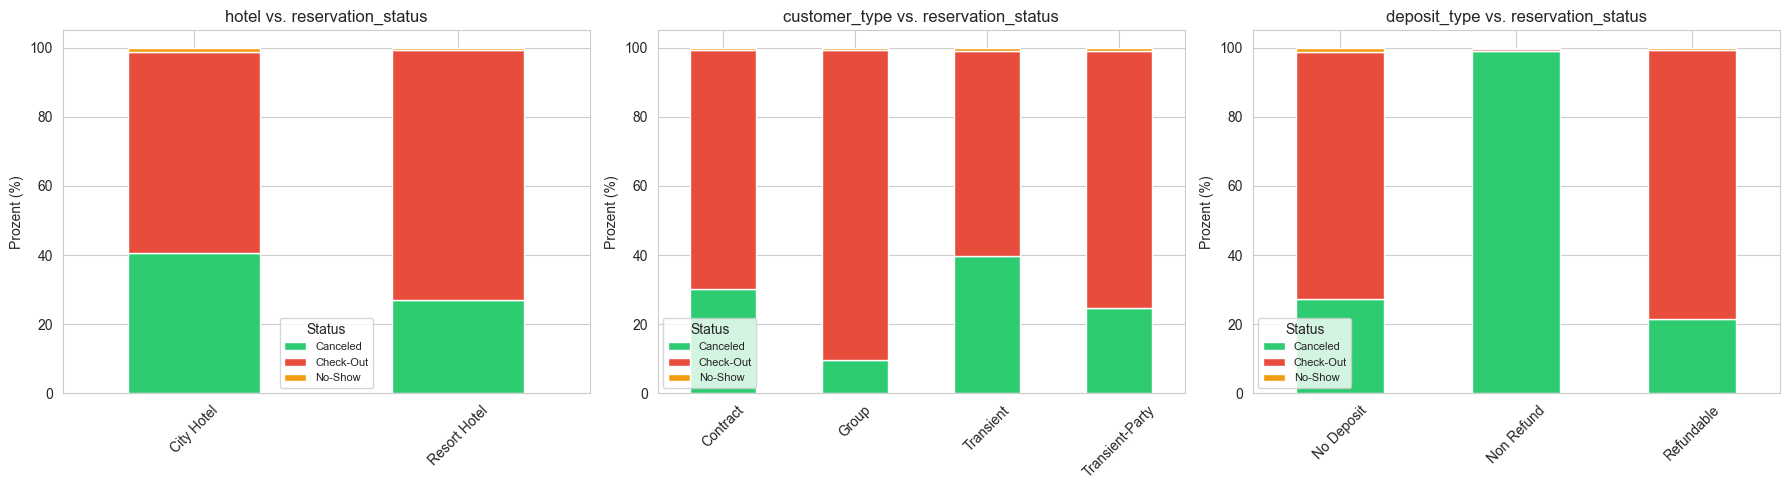

In [7]:
# Kategorische Features vs. Target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['hotel', 'customer_type', 'deposit_type']):
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c', '#f39c12'])
    ax.set_title(f'{col} vs. {target}', fontsize=12)
    ax.set_ylabel('Prozent (%)')
    ax.set_xlabel('')
    ax.legend(title='Status', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3 | Feature Engineering & Preprocessing

In [8]:
# Leakage-Spalten entfernen
df = df.drop(columns=hb_cfg['drop_columns'])

# Neue Features
df['total_stays'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'].fillna(0) + df['babies']

# Country: Top 10 behalten, Rest = 'Other'
top_countries = df['country'].value_counts().head(10).index
df['country'] = df['country'].where(df['country'].isin(top_countries), 'Other')

print(f'Shape nach Feature Engineering: {df.shape}')
print(f'Neue Features: total_stays, total_guests')
print(f'Country reduziert auf {df["country"].nunique()} Kategorien')

Shape nach Feature Engineering: (119390, 31)
Neue Features: total_stays, total_guests
Country reduziert auf 11 Kategorien


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Target und Features trennen
y = df[target]
X = df.drop(columns=[target])

# Kategorische Spalten encoden
cat_cols = X.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Target encoden
le_target = LabelEncoder()
y = le_target.fit_transform(y)
print(f'Klassen: {list(le_target.classes_)}')
print(f'Encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

# Fehlende Werte auffuellen
X = X.fillna(0)

# Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=hb_cfg['test_size'],
    random_state=cfg['random_seed'], stratify=y
)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Klassenverteilung Train: {np.bincount(y_train)}')
print(f'Klassenverteilung Test:  {np.bincount(y_test)}')

Klassen: ['Canceled', 'Check-Out', 'No-Show']
Encoding: {'Canceled': np.int64(0), 'Check-Out': np.int64(1), 'No-Show': np.int64(2)}

Train: (95512, 30), Test: (23878, 30)
Klassenverteilung Train: [34413 60133   966]
Klassenverteilung Test:  [ 8604 15033   241]


## 4 | Baseline-Modell: Logistische Regression

=== Logistische Regression ===
              precision    recall  f1-score   support

    Canceled       0.74      0.64      0.69      8604
   Check-Out       0.86      0.58      0.69     15033
     No-Show       0.03      0.70      0.05       241

    accuracy                           0.60     23878
   macro avg       0.54      0.64      0.48     23878
weighted avg       0.81      0.60      0.68     23878



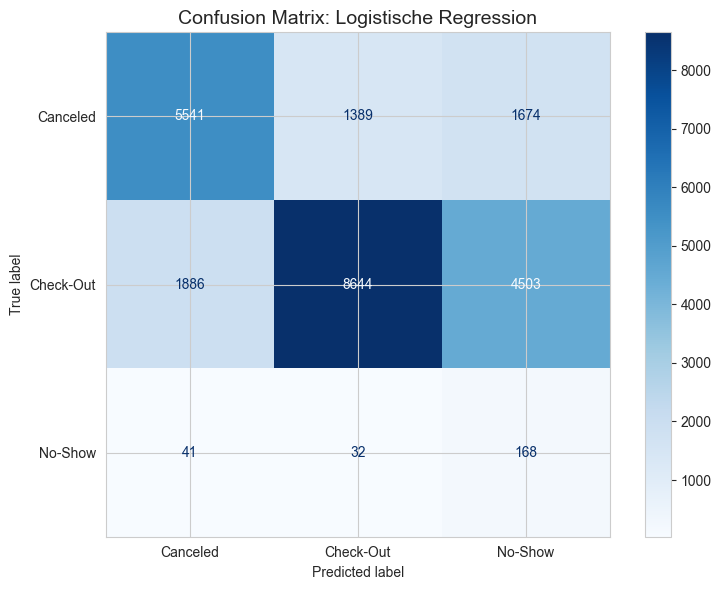

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Skalierung fuer LogReg
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistische Regression (Multiclass)
log_reg = LogisticRegression(max_iter=1000, random_state=cfg['random_seed'],
                             class_weight='balanced', multi_class='multinomial')
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print('=== Logistische Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=le_target.classes_,
                                         cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix: Logistische Regression', fontsize=14)
plt.tight_layout()
plt.show()

## 5 | Modellvergleich

In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

# Modelle definieren
models = {
    'Logistische Regression': (log_reg, X_test_scaled),
    'Random Forest': (RandomForestClassifier(
        n_estimators=200, random_state=cfg['random_seed'],
        class_weight='balanced', n_jobs=-1
    ), X_test),
    'Gradient Boosting': (GradientBoostingClassifier(
        n_estimators=200, random_state=cfg['random_seed'],
        max_depth=5, learning_rate=0.1
    ), X_test),
}

# Trainieren und evaluieren
results = []
predictions = {}

for name, (model, X_eval) in models.items():
    X_tr = X_train_scaled if 'Logistisch' in name else X_train
    if name != 'Logistische Regression':
        model.fit(X_tr, y_train)
    y_pred = model.predict(X_eval)
    predictions[name] = y_pred
    results.append({
        'Modell': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro F1': f1_score(y_test, y_pred, average='macro'),
        'Weighted F1': f1_score(y_test, y_pred, average='weighted'),
    })

results_df = pd.DataFrame(results).set_index('Modell')
display(results_df.round(4))

,Accuracy,Macro F1,Weighted F1
Modell,,,
Logistische Regression,0.6011,0.4765,0.6826
Random Forest,0.8880,0.7174,0.8855
Gradient Boosting,0.8761,0.6633,0.8728


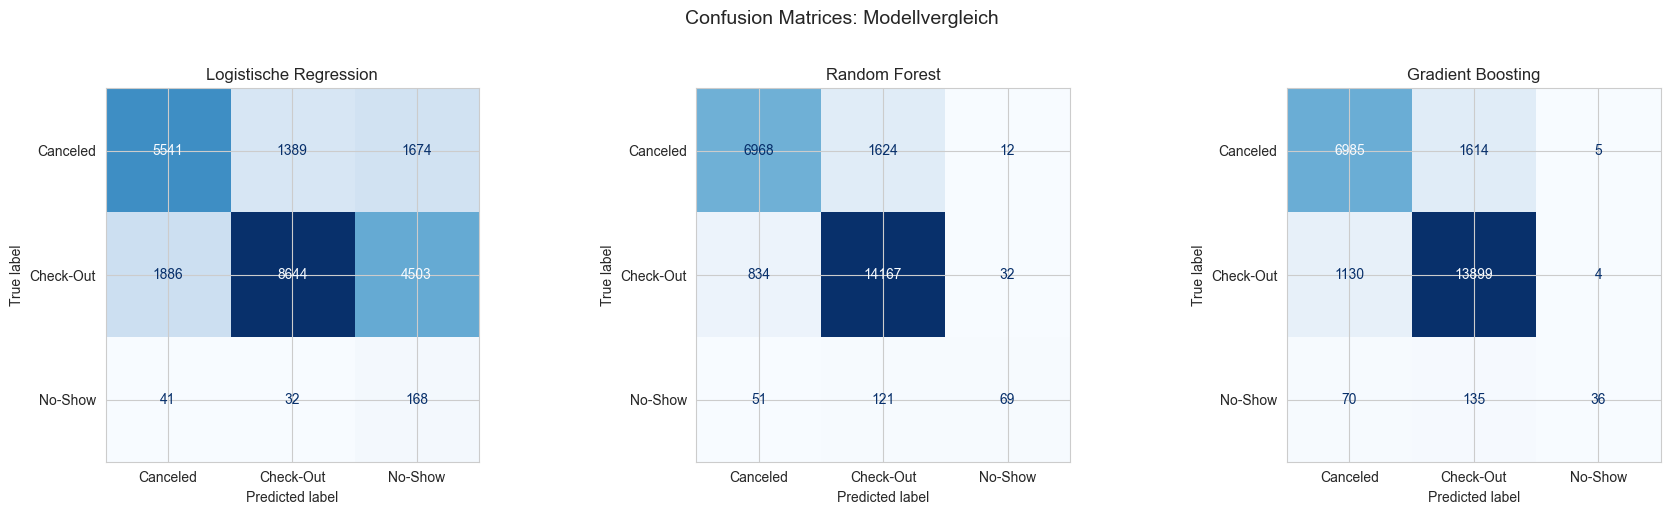

In [12]:
# Confusion Matrices im Vergleich
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le_target.classes_,
                                             cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices: Modellvergleich', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

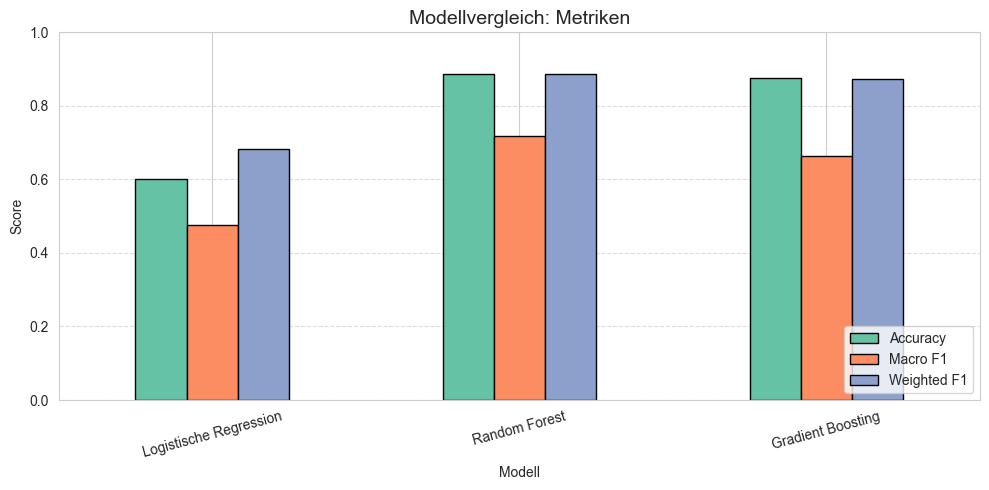

In [13]:
# Metriken-Vergleich als Barplot
results_df.plot(kind='bar', figsize=(10, 5), rot=15, edgecolor='black')
plt.title('Modellvergleich: Metriken', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6 | Hyperparameter-Optimierung

Wir optimieren das beste Modell aus dem Vergleich mit `RandomizedSearchCV`.
Das spart Zeit gegenueber `GridSearchCV` bei vielen Parameterkombinationen.

In [14]:
from sklearn.model_selection import RandomizedSearchCV

# Bestes Modell identifizieren
best_model_name = results_df['Macro F1'].idxmax()
print(f'Bestes Modell: {best_model_name}')

# Hyperparameter-Raeume
param_distributions = {
    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'min_samples_split': [2, 5, 10],
        'subsample': [0.8, 0.9, 1.0],
    },
}

# Falls LogReg bestes Modell ist, optimieren wir stattdessen den besten Tree-Classifier
if best_model_name == 'Logistische Regression':
    best_model_name = results_df.drop('Logistische Regression')['Macro F1'].idxmax()
    print(f'Tree-basiertes Modell fuer Optimierung: {best_model_name}')

base_model = models[best_model_name][0].__class__(
    random_state=cfg['random_seed'],
    **({"class_weight": "balanced", "n_jobs": -1} if "Random Forest" in best_model_name else {})
)

search = RandomizedSearchCV(
    base_model,
    param_distributions[best_model_name],
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=cfg['random_seed'],
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print(f'\nBeste Parameter: {search.best_params_}')
print(f'Bester CV Macro F1: {search.best_score_:.4f}')

Bestes Modell: Random Forest
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Beste Parameter: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Bester CV Macro F1: 0.7009


=== Optimiertes Random Forest ===
              precision    recall  f1-score   support

    Canceled       0.86      0.83      0.85      8604
   Check-Out       0.90      0.93      0.91     15033
     No-Show       0.59      0.31      0.40       241

    accuracy                           0.89     23878
   macro avg       0.78      0.69      0.72     23878
weighted avg       0.88      0.89      0.88     23878

Macro F1 vorher:  0.7174
Macro F1 nachher: 0.7218


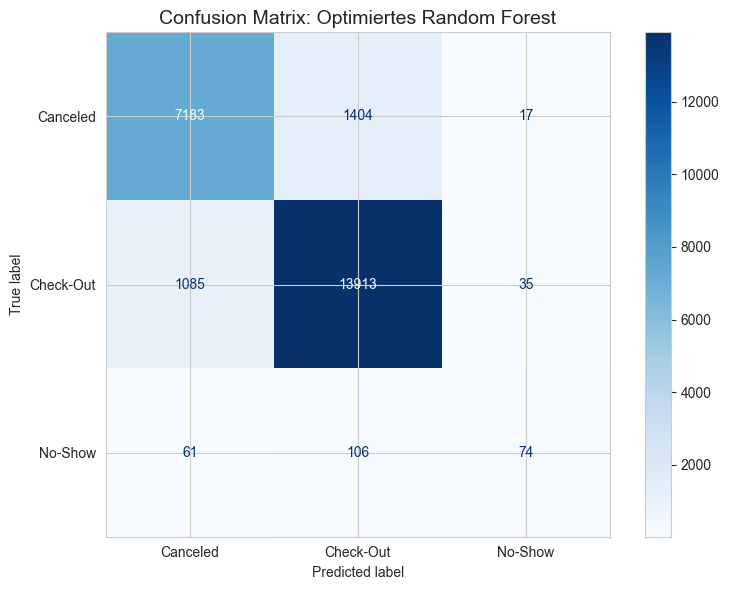

In [15]:
# Optimiertes Modell evaluieren
y_pred_opt = search.best_estimator_.predict(X_test)

print(f'=== Optimiertes {best_model_name} ===')
print(classification_report(y_test, y_pred_opt, target_names=le_target.classes_))

# Vergleich vorher/nachher
print(f'Macro F1 vorher:  {results_df.loc[best_model_name, "Macro F1"]:.4f}')
print(f'Macro F1 nachher: {f1_score(y_test, y_pred_opt, average="macro"):.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, display_labels=le_target.classes_,
                                         cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix: Optimiertes {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

## 7 | Feature Importance

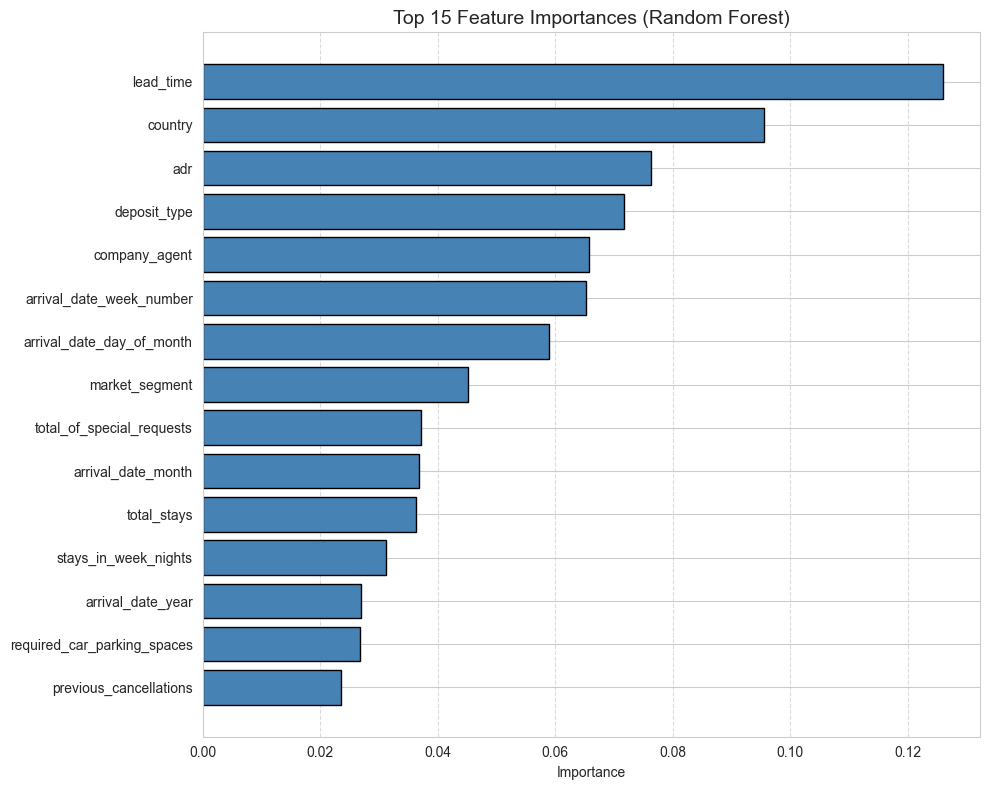

In [16]:
# Feature Importance des optimierten Modells
importances = search.best_estimator_.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='black')
plt.title(f'Top 15 Feature Importances ({best_model_name})', fontsize=14)
plt.xlabel('Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 8 | Fazit

**Zusammenfassung:**
- Der Hotel-Bookings-Datensatz wurde fuer eine Multiclass-Klassifikation (Check-Out / Canceled / No-Show) aufbereitet.
- Data Leakage wurde durch Entfernung von `is_canceled` und `reservation_status_date` verhindert.
- Drei Modelle (Logistische Regression, Random Forest, Gradient Boosting) wurden verglichen.
- Das beste Modell wurde per RandomizedSearchCV optimiert.

**Herausforderungen:**
- **Class Imbalance:** No-Show ist eine sehr seltene Klasse und damit schwer vorherzusagen.
- `class_weight='balanced'` hilft, reicht aber bei extremer Imbalance nicht immer aus.
- Fuer Produktionsszenarien waeren Oversampling (SMOTE) oder angepasste Schwellenwerte sinnvoll.